# Model Fine-Tuning

This notebook focuses on the **fine-tuning and evaluation of multiple machine learning models** for the task of **patent novelty classification**. The objective is to automatically categorize patent documents into different **novelty tiers** based on their textual content.

The models evaluated in this study include:

- Multinomial Naive Bayes  
- Logistic Regression  
- Support Vector Machine (SVM)  
- Random Forest  
- Gradient Boosting  
- XGBoost  

By comparing these models, the goal is to identify the **most effective approach for predicting patent novelty tiers from textual data**. The results of this analysis provide insights into how different machine learning techniques perform on structured patent datasets.

### Step 1 - Importing Required Libraries

In this notebook, several machine learning and data processing libraries are used to build and fine-tune models for patent novelty classification. These libraries collectively support the full pipeline, including feature extraction, model training, hyperparameter tuning, and performance evaluation.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import pandas as pd

### Step 2 - Loading the Balanced Patent Dataset and Defining Variables

In this step, the **balanced patent dataset** prepared during the preprocessing stage is loaded.  
The dataset contains cleaned patent text along with their corresponding **novelty tier labels**, which represent the level of innovation of each patent.

Separating the dataset into features and labels prepares the data for **text vectorization and machine learning model training** in the subsequent steps.

In [92]:

df = pd.read_csv("final_patent_dataset_balanced.csv")

print("Dataset loaded:", df.shape)

print(df.head())


Dataset loaded: (5000, 2)
                                          clean_text  novelty tier
0  methods systems providing proximity process re...             1
1  gateway anti theft security improved systems t...             2
2  managed shutdown distributed begins load balan...             2
3  semiconductor graphic wiring area semiconducto...             0
4  controlling virtualized functions receive proc...             0


In [93]:
X_text = df["clean_text"]

y = df["novelty tier"]


### Step 3 - TF-IDF Feature Extraction

Machine learning models require numerical input. Therefore, the patent text must be converted into numerical vectors.

This is achieved using **TF-IDF (Term Frequency – Inverse Document Frequency)**.

Key TF-IDF configuration used:

- **max_features = 15000**
  - Limits the vocabulary to the 15,000 most informative terms.

- **ngram_range = (1,3)**
  - Includes unigrams, bigrams, and trigrams to capture contextual phrases.

- **min_df = 3**
  - Ignores words that appear in fewer than 3 documents.

- **max_df = 0.85**
  - Removes overly common words appearing in more than 85% of documents.

- **sublinear_tf = True**
  - Applies logarithmic scaling to term frequency.

This step converts patent text into a **sparse TF-IDF feature matrix**.

In [118]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X = vectorizer.fit_transform(X_text)

print("TF-IDF shape:", X.shape)


TF-IDF shape: (5000, 15000)


#### Top TF-IDF Words by Novelty Tier

TF-IDF analysis is used to identify the most important words associated with each **novelty tier** in the patent dataset.

**TF-IDF (Term Frequency–Inverse Document Frequency)** highlights terms that appear frequently in a specific tier but are less common across the overall dataset.

**Method**
1. Filter patent texts by **novelty tier**.
2. Convert the text into **TF-IDF vectors** using the trained vectorizer.
3. Compute the **average TF-IDF score** for each term within the tier.
4. Select the **top words with the highest scores**.
5. Visualize them using a **bar chart**.

This analysis helps identify key terminology patterns that distinguish patents across different **novelty levels**.

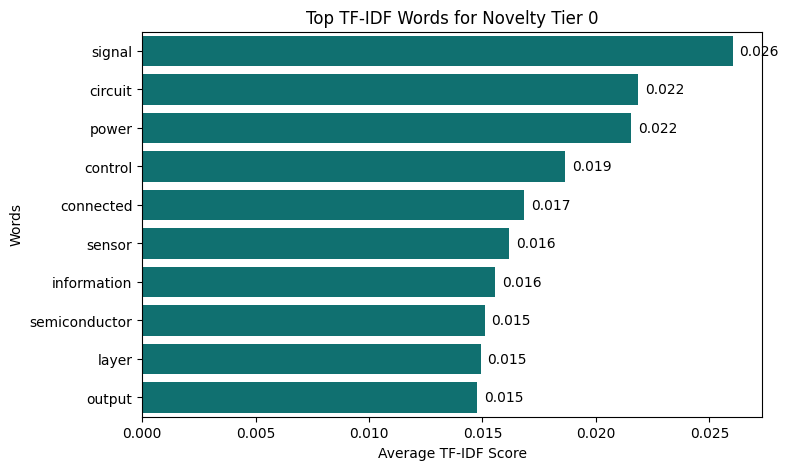

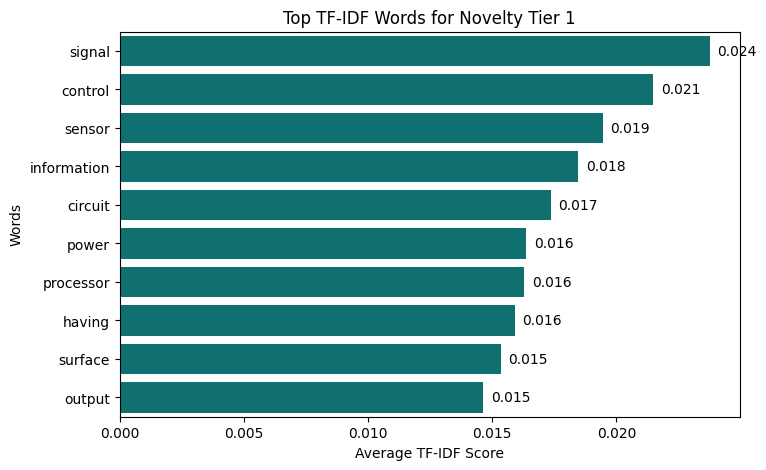

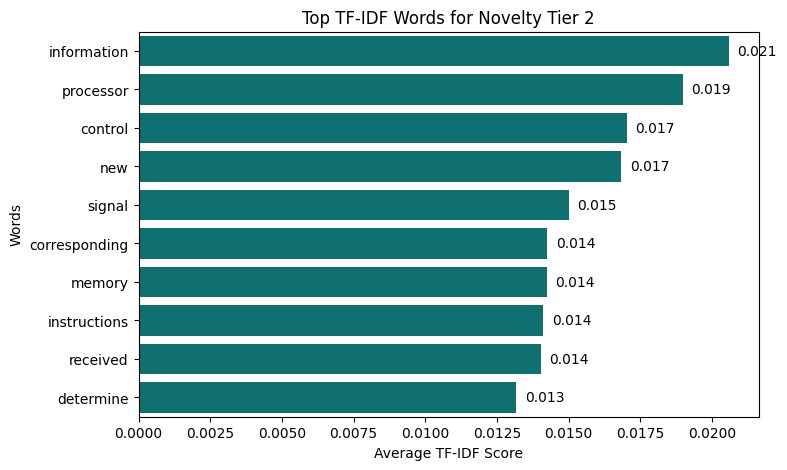

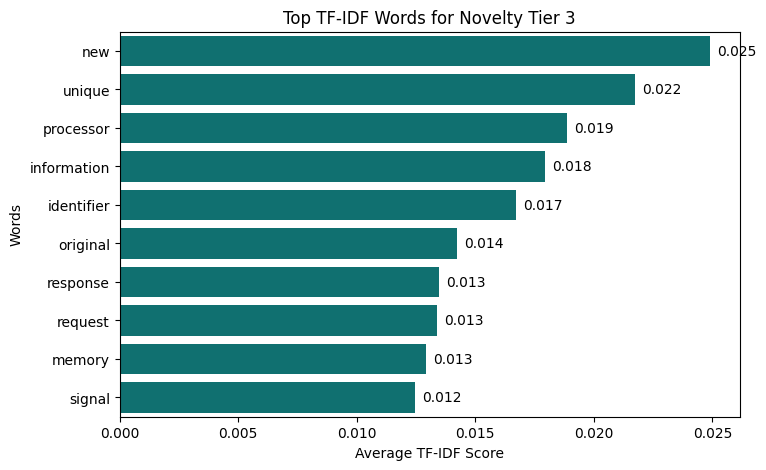

In [117]:

feature_names = vectorizer.get_feature_names_out()

def get_top_tfidf_words(dataframe, tier, top_n=10):

    texts = dataframe[dataframe["novelty tier"] == tier]["clean_text"]

    tfidf_matrix = vectorizer.transform(texts)

    avg_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    top_indices = avg_scores.argsort()[-top_n:][::-1]

    words = [feature_names[i] for i in top_indices]
    scores = avg_scores[top_indices]

    return pd.DataFrame({
        "word": words,
        "score": scores
    })


for tier in sorted(df["novelty tier"].unique()):

    df_words = get_top_tfidf_words(df, tier)

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        x="score",
        y="word",
        data=df_words,
        color="teal"
    )

    for i, v in enumerate(df_words["score"]):
        ax.text(v + 0.0003, i, f"{v:.3f}", va="center")

    plt.title(f"Top TF-IDF Words for Novelty Tier {tier}")
    plt.xlabel("Average TF-IDF Score")
    plt.ylabel("Words")

    plt.show()

### Step 4 - Feature Selection using Chi-Square Test

The TF-IDF vectorization generates a large number of features. However, not all features contribute equally to classification.

To improve model performance and reduce noise, **Chi-Square feature selection** is applied.

- **Method:** `SelectKBest`
- **Statistical Test:** Chi-Square (χ²)
- **Selected Features:** 8000

This step retains the **most informative textual features** that have the strongest relationship with the novelty tier labels.

In [95]:
selector = SelectKBest(chi2, k=8000)

X = selector.fit_transform(X, y)

print("After feature selection:", X.shape)

After feature selection: (5000, 8000)


### Step 5 - Train-Test Dataset Split

To evaluate model performance fairly, the dataset is divided into:

- **Training Set (80%)**
- **Testing Set (20%)**

Key parameters:

- **random_state = 42**
  - Ensures reproducibility.

- **stratify = y**
  - Maintains equal class distribution across training and testing sets.

This ensures that each novelty tier is represented proportionally in both sets.

In [96]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4000, 8000)
Test: (1000, 8000)


### Step 6 - Machine Learning Models for Fine-Tuning

Multiple machine learning algorithms are evaluated to determine the most effective model for patent novelty classification. The models tested include:

1. **Multinomial Naive Bayes**
   - Commonly used for text classification tasks.

2. **Logistic Regression**
   - A strong linear baseline for text data.

3. **Support Vector Machine (Linear SVM)**
   - Effective for high-dimensional sparse datasets such as TF-IDF.

4. **Random Forest**
   - Ensemble tree model capable of capturing nonlinear relationships.

5. **Gradient Boosting**
   - Sequential ensemble method that improves prediction accuracy.

6. **XGBoost**
   - Advanced gradient boosting algorithm optimized for performance and scalability.

Each model is later fine-tuned using hyperparameter optimization.

In [97]:
models = {

    "Multinomial Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(max_iter=3000),

    "Support Vector Machine": LinearSVC(),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        use_label_encoder=False
    )

}

### Step 7 - Hyperparameter Grid for Fine-Tuning

To optimize model performance, a **Grid Search** strategy is used.

Grid Search systematically tests different hyperparameter combinations to identify the best configuration.

Examples of tuned parameters:

| Model | Tuned Parameters |
|------|------------------|
| Naive Bayes | alpha |
| Logistic Regression | C |
| SVM | C |
| Random Forest | n_estimators, max_depth |
| Gradient Boosting | learning_rate, n_estimators |
| XGBoost | max_depth, learning_rate, n_estimators |

Each model undergoes **cross-validation to select the best performing parameter set**.

In [98]:
param_grids = {

    "Multinomial Naive Bayes": {
        "alpha": [0.1, 0.5, 1]
    },

    "Logistic Regression": {
        "C": [0.1, 1, 5]
    },

    "Support Vector Machine": {
        "C": [0.5, 1, 2]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 20]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1]
    },

    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [4, 6],
        "learning_rate": [0.05, 0.1]
    }

}

### Step 8 - Model Fine-Tuning using GridSearchCV

To improve model performance, **GridSearchCV** is used to perform systematic hyperparameter tuning.

Key configuration:

- **Cross Validation:** 5-fold
- **Scoring Metric:** Macro F1 Score
- **Parallel Processing:** Enabled using `n_jobs = -1`

Macro F1 is selected as the evaluation metric because:

- The problem is **multi-class classification**.
- It ensures **balanced evaluation across all novelty tiers**.

For each model, the following steps are performed:

1. Train multiple hyperparameter configurations
2. Perform cross-validation
3. Select the best performing model
4. Evaluate it on the test dataset

In [99]:
results = {}
best_models = {}

for name, model in models.items():

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test)

    results[name] = {
        "best_params": grid.best_params_,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(y_test, predictions, average="macro"),
        "precision": precision_score(y_test, predictions, average="macro"),
        "recall": recall_score(y_test, predictions, average="macro"),
        "report": classification_report(y_test, predictions),
        "cm": confusion_matrix(y_test, predictions)
    }


C:\Users\jewel\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:13:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Step 9 - Model Performance Evaluation

After fine-tuning, each model is evaluated using multiple performance metrics:

- **Accuracy**
  - Overall prediction correctness.

- **Macro F1 Score**
  - Balanced evaluation across all classes.

- **Precision**
  - Correctness of predicted labels.

- **Recall**
  - Ability to detect true instances of each class.

Additionally, the following diagnostic outputs are generated:

- **Classification Report**
- **Confusion Matrix**

These metrics provide a comprehensive understanding of model performance.

#### i. Multinomial Naive Bayes Results

The Multinomial Naive Bayes model achieved an **accuracy of 0.798** and a **macro F1-score of 0.8003**, showing moderate performance for patent novelty classification.

The model performs **best on Tier 3**, indicating that highly novel patents are easier to identify. **Tier 2 also shows reasonably balanced performance**. However, the model struggles more with **Tier 0 and Tier 1**, where some misclassification occurs due to similarities in their textual patterns.

Overall, Multinomial Naive Bayes provides a **strong baseline for text classification**, though more advanced models may capture deeper patterns and improve accuracy.

In [100]:
name = "Multinomial Naive Bayes"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])
print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

Multinomial Naive Bayes Results
Accuracy   : 0.798
Macro F1   : 0.8003
Precision  : 0.8096
Recall     : 0.798
Best Parameters: {'alpha': 0.1}

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       250
           1       0.65      0.74      0.69       250
           2       0.76      0.84      0.80       250
           3       0.97      0.91      0.94       250

    accuracy                           0.80      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000

Confusion Matrix:
[[175  60  14   1]
 [ 19 184  43   4]
 [  6  30 211   3]
 [  3  11   8 228]]


#### ii. Logistic Regression Results

The Logistic Regression model achieved an **accuracy of 0.893** and a **macro F1-score of 0.8927**, showing a significant improvement over the Naive Bayes baseline.

The model performs **very well on Tier 2 and Tier 3**, with high precision and recall values, indicating strong ability to identify more innovative patents. Performance on **Tier 0 and Tier 1 is also balanced**, though some confusion remains between these adjacent tiers.

Overall, Logistic Regression demonstrates **strong and consistent performance for text classification**, effectively leveraging TF-IDF features to distinguish between different patent novelty levels.

In [101]:
name = "Logistic Regression"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])
print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

Logistic Regression Results
Accuracy   : 0.893
Macro F1   : 0.8927
Precision  : 0.8932
Recall     : 0.893
Best Parameters: {'C': 5}

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       250
           1       0.84      0.80      0.82       250
           2       0.93      0.91      0.92       250
           3       0.97      0.99      0.98       250

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000

Confusion Matrix:
[[218  29   2   1]
 [ 36 200  12   2]
 [ 10   8 228   4]
 [  0   0   3 247]]


#### iii. Support Vector Machine Results

The Support Vector Machine (SVM) model achieved an **accuracy of 0.897** and a **macro F1-score of 0.8969**, indicating strong overall performance in classifying patent novelty tiers.

The model performs **particularly well on Tier 2 and Tier 3**, with very high precision and recall, showing its effectiveness in identifying more innovative patents. Performance for **Tier 0 and Tier 1 is also balanced**, though minor confusion exists between these neighboring tiers.

Overall, SVM demonstrates **high reliability for high-dimensional text data**, making it a strong model for patent novelty classification.

In [102]:
name = "Support Vector Machine"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])
print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

Support Vector Machine Results
Accuracy   : 0.897
Macro F1   : 0.8969
Precision  : 0.8976
Recall     : 0.897
Best Parameters: {'C': 2}

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       250
           1       0.85      0.80      0.82       250
           2       0.94      0.92      0.93       250
           3       0.98      0.98      0.98       250

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000

Confusion Matrix:
[[220  28   2   0]
 [ 39 200  10   1]
 [  8   7 231   4]
 [  0   0   4 246]]


#### iv. Random Forest Results

The Random Forest model achieved an **accuracy of 0.927** and a **macro F1-score of 0.9278**, indicating strong performance in predicting patent novelty tiers.

The model performs **very well across all tiers**, with particularly high precision and recall for **Tier 2 and Tier 3**, showing its effectiveness in identifying highly innovative patents. Minor confusion occurs between **Tier 0 and Tier 1**, which is expected due to similarities in their textual features.

Overall, Random Forest provides **robust and balanced classification performance**, benefiting from its ensemble learning approach.

In [103]:
name = "Random Forest"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])
print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

Random Forest Results
Accuracy   : 0.918
Macro F1   : 0.9187
Precision  : 0.9201
Recall     : 0.918
Best Parameters: {'max_depth': None, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       250
           1       0.83      0.88      0.85       250
           2       0.97      0.94      0.95       250
           3       1.00      0.98      0.99       250

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix:
[[217  30   3   0]
 [ 24 221   5   0]
 [  2  13 235   0]
 [  2   3   0 245]]


#### v. Gradient Boosting Results

The Gradient Boosting model achieved an **accuracy of 0.923** and a **macro F1-score of 0.9225**, demonstrating strong performance for patent novelty classification.

The model performs **particularly well on Tier 2 and Tier 3**, with high precision and recall values, indicating effective detection of more innovative patents. Some minor confusion occurs between **Tier 0 and Tier 1**, likely due to similarities in their textual patterns.

Overall, Gradient Boosting provides **accurate and balanced classification performance**, benefiting from its ability to iteratively improve predictions through boosting.

In [104]:
name = "Gradient Boosting"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])
print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

Gradient Boosting Results
Accuracy   : 0.921
Macro F1   : 0.9204
Precision  : 0.9203
Recall     : 0.921
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       250
           1       0.88      0.86      0.87       250
           2       0.93      0.94      0.94       250
           3       0.95      1.00      0.98       250

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix:
[[221  28   1   0]
 [ 18 215  16   1]
 [  2   2 235  11]
 [  0   0   0 250]]


#### vi. XGBoost Results

The XGBoost model achieved the **highest performance**, with an **accuracy of 0.943** and a **macro F1-score of 0.9425**, making it the best-performing model among all evaluated algorithms.

The model shows **excellent classification across all novelty tiers**, particularly for **Tier 2 and Tier 3**, where precision and recall are extremely high. The confusion matrix also shows **very few misclassifications**, indicating that XGBoost is highly effective at capturing complex patterns in the patent text.

Overall, XGBoost demonstrates **superior predictive capability and balanced performance**, making it the most suitable model for patent novelty classification in this study.

In [105]:
name = "XGBoost"
r = results[name]

print(name, "Results")
print("Accuracy   :", round(r["accuracy"],4))
print("Macro F1   :", round(r["macro_f1"],4))
print("Precision  :", round(r["precision"],4))
print("Recall     :", round(r["recall"],4))
print("Best Parameters:", r["best_params"])

print("\nClassification Report:")
print(r["report"])

print("Confusion Matrix:")
print(r["cm"])

XGBoost Results
Accuracy   : 0.943
Macro F1   : 0.9425
Precision  : 0.9426
Recall     : 0.943
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       250
           1       0.91      0.88      0.89       250
           2       0.94      0.99      0.96       250
           3       0.99      1.00      1.00       250

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000

Confusion Matrix:
[[226  21   3   0]
 [ 17 219  14   0]
 [  0   0 248   2]
 [  0   0   0 250]]


## Model Performance Visualization

To better understand the performance differences between the trained models, several visualizations were generated.

The following plots summarize the model comparison:

1. **Accuracy Comparison Bar Chart**  
   Shows how well each model performs in terms of overall prediction accuracy.

2. **Macro F1 Score Comparison**  
   Highlights how balanced each model performs across all novelty tiers.

3. **Confusion Matrix Heatmaps**  
   Displays how each model predicts the different novelty tiers and helps identify common misclassification patterns.

4. **Precision vs Recall Comparison**  
   Illustrates the balance between precision and recall for each model, providing insight into how reliably the models identify each novelty tier without excessive misclassification.

These visualizations provide an intuitive comparison of the machine learning models and help identify the **best-performing approach for patent novelty classification**.

In [106]:
results_df = pd.DataFrame.from_dict(results, orient="index")

results_df = results_df.reset_index().rename(columns={
    "index": "Model",
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
    "precision": "Precision",
    "recall": "Recall"
})

results_df

,Model,best_params,Accuracy,Macro F1,Precision,Recall,report,cm
0,Multinomial Naive Bayes,{'alpha': 0.1},0.798,0.800258,0.809569,0.798,precision recall f1-score ...,"[[175, 60, 14, 1], [19, 184, 43, 4], [6, 30, 2..."
1,Logistic Regression,{'C': 5},0.893,0.892744,0.893173,0.893,precision recall f1-score ...,"[[218, 29, 2, 1], [36, 200, 12, 2], [10, 8, 22..."
2,Support Vector Machine,{'C': 2},0.897,0.896855,0.897584,0.897,precision recall f1-score ...,"[[220, 28, 2, 0], [39, 200, 10, 1], [8, 7, 231..."
3,Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.918,0.918736,0.920127,0.918,precision recall f1-score ...,"[[217, 30, 3, 0], [24, 221, 5, 0], [2, 13, 235..."
4,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 200}",0.921,0.920427,0.920325,0.921,precision recall f1-score ...,"[[221, 28, 1, 0], [18, 215, 16, 1], [2, 2, 235..."
5,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.943,0.942459,0.942613,0.943,precision recall f1-score ...,"[[226, 21, 3, 0], [17, 219, 14, 0], [0, 0, 248..."


#### i. Model Accuracy and Macro F1 Comparison

The comparison charts show the performance of all models in terms of **accuracy** and **macro F1 score**. Among the models, **XGBoost achieved the highest performance**, with an accuracy of **0.943** and macro F1 score of **0.942**, indicating the most reliable classification of patent novelty tiers.

**Random Forest and Gradient Boosting** also performed strongly, demonstrating the effectiveness of ensemble methods for text classification. In contrast, **Multinomial Naive Bayes showed the lowest performance**, serving mainly as a baseline model.

Overall, the results indicate that **tree-based ensemble models outperform simpler linear models for this task**, with XGBoost providing the best balance of accuracy and class-wise performance.

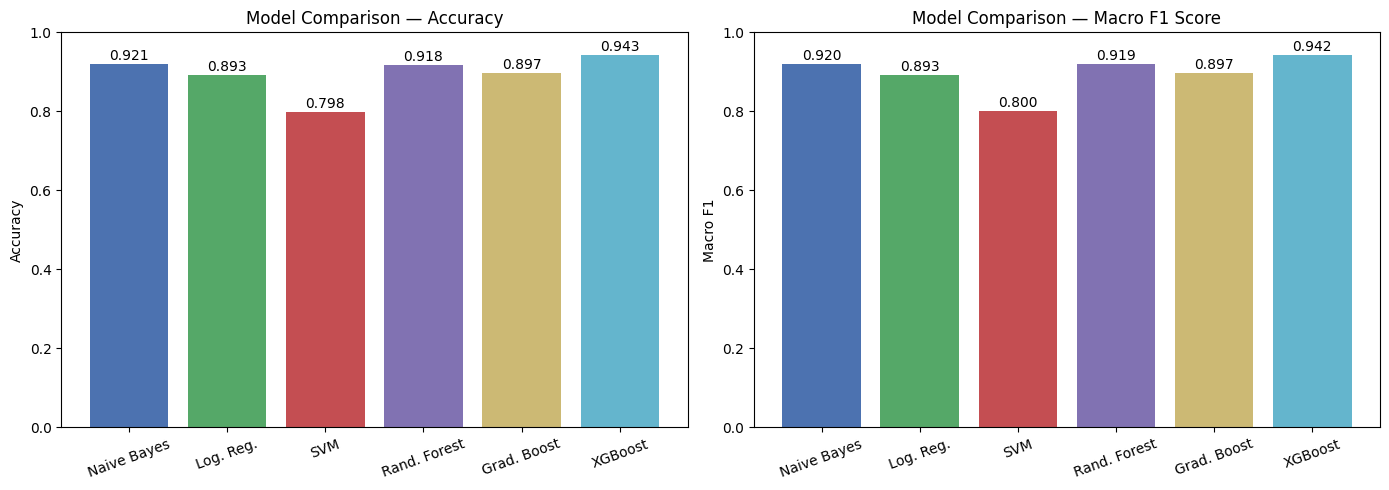

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]

models_short = [
    "Naive Bayes",
    "Log. Reg.",
    "SVM",
    "Rand. Forest",
    "Grad. Boost",
    "XGBoost"
]

sorted_df = results_df.sort_values("Model")

axes[0].bar(models_short, sorted_df["Accuracy"].values, color=colors)

axes[0].set_title("Model Comparison — Accuracy", fontsize=12)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[0].tick_params(axis='x', rotation=20)

for i, v in enumerate(sorted_df["Accuracy"].values):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')


axes[1].bar(models_short, sorted_df["Macro F1"].values, color=colors)

axes[1].set_title("Model Comparison — Macro F1 Score", fontsize=12)
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)

axes[1].tick_params(axis='x', rotation=20)

for i, v in enumerate(sorted_df["Macro F1"].values):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center')


plt.tight_layout()
plt.show()

#### ii. Confusion Matrix Comparison

The confusion matrices show how accurately each model predicts the different **novelty tiers**. Most models correctly classify **Tier 2 and Tier 3**, indicating that highly innovative patents are easier to distinguish. Some confusion occurs between **Tier 0 and Tier 1**, as these tiers have more similar textual characteristics.

Among all models, **XGBoost shows the cleanest confusion matrix**, with the highest number of correct predictions and very few misclassifications. **Random Forest and Gradient Boosting** also perform strongly, while **Naive Bayes shows more misclassification**, particularly between adjacent tiers.

Overall, the confusion matrices confirm that **ensemble models provide more accurate and consistent predictions for patent novelty classification**.

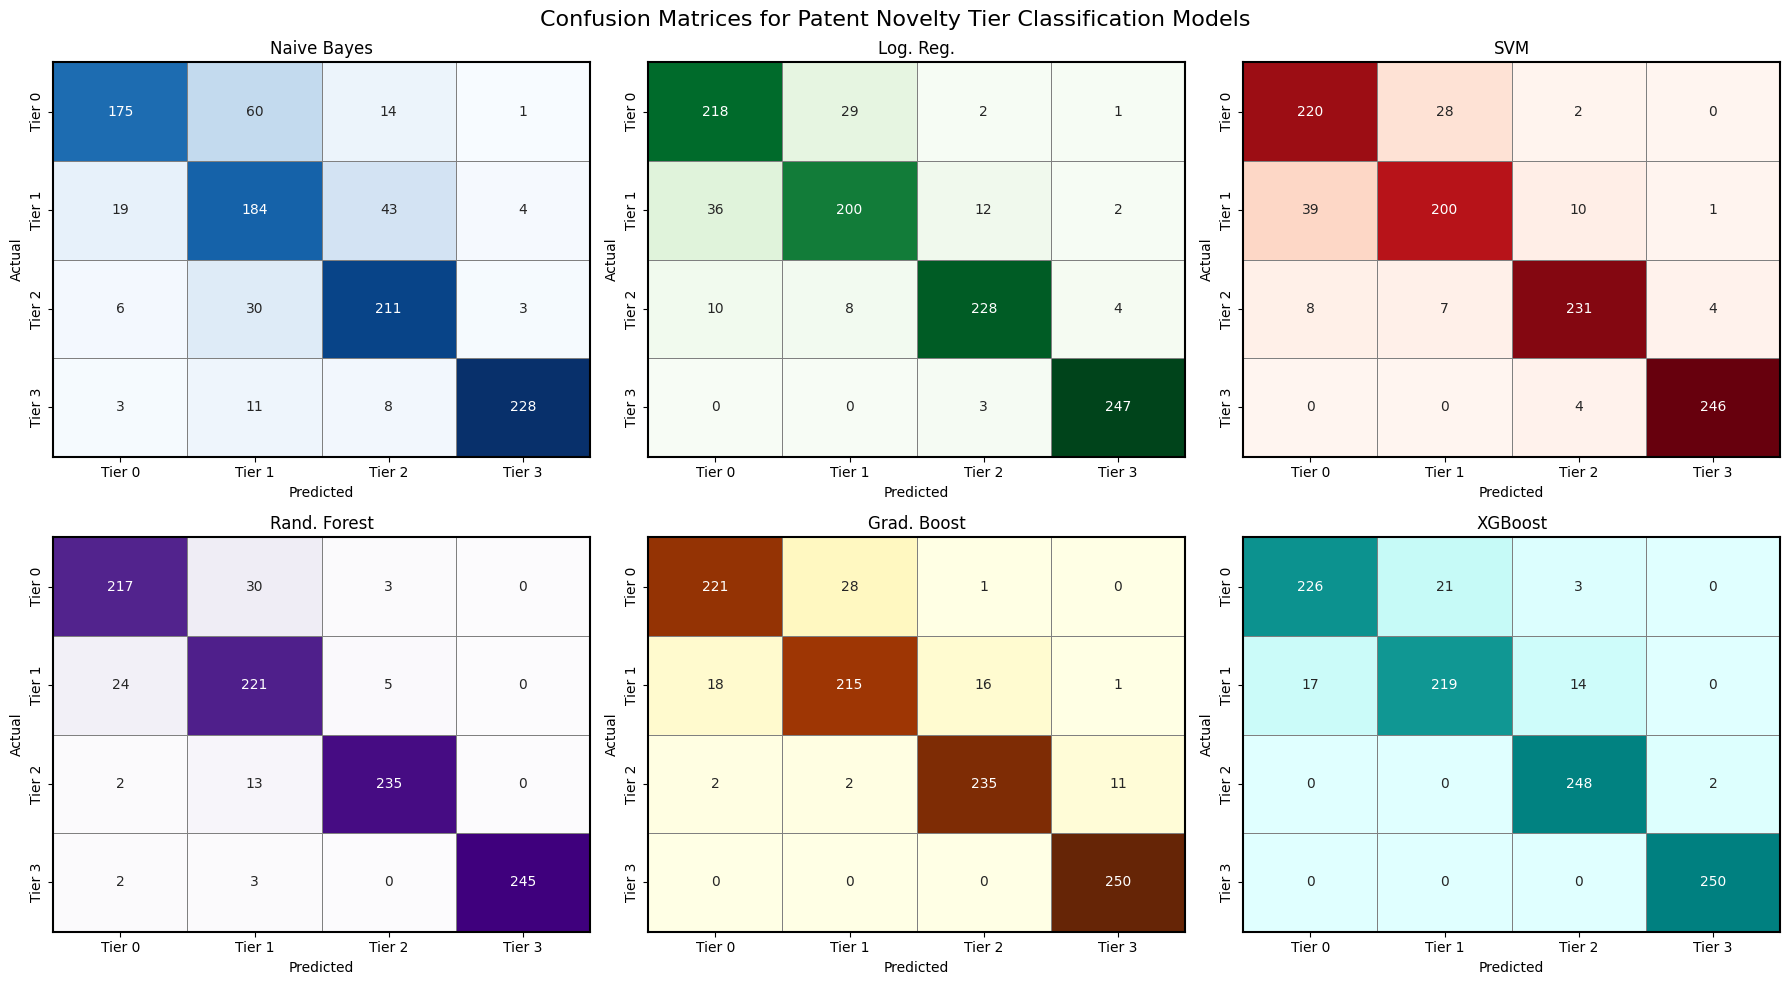

In [ ]:
turquoise_teal = LinearSegmentedColormap.from_list(
    "turquoise_teal",
    ["#E0FFFF", "#40E0D0", "#008080"]
)

model_colors = {
    "Multinomial Naive Bayes": "Blues",
    "Logistic Regression": "Greens",
    "Support Vector Machine": "Reds",
    "Random Forest": "Purples",
    "Gradient Boosting": "YlOrBr",
    "XGBoost": turquoise_teal
}

models_short = {
    "Multinomial Naive Bayes": "Naive Bayes",
    "Logistic Regression": "Log. Reg.",
    "Support Vector Machine": "SVM",
    "Random Forest": "Rand. Forest",
    "Gradient Boosting": "Grad. Boost",
    "XGBoost": "XGBoost"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, model in enumerate(results):

    sns.heatmap(
        results[model]["cm"],
        annot=True,
        fmt="d",
        cmap=model_colors[model],
        xticklabels=["Tier 0","Tier 1","Tier 2","Tier 3"],
        yticklabels=["Tier 0","Tier 1","Tier 2","Tier 3"],
        linewidths=0.5,
        linecolor="gray",
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(models_short[model])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

    # Add subplot border
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

plt.suptitle("Confusion Matrices for Patent Novelty Tier Classification Models", fontsize=16)

plt.tight_layout()
plt.show()

### iii. Precision vs Recall Comparison

The Precision vs Recall comparison shows that most models maintain a **good balance between precision and recall**, indicating stable and reliable classification performance.

**XGBoost achieves the highest precision and recall**, confirming its superior ability to correctly identify patent novelty tiers while minimizing misclassification. **Random Forest and Gradient Boosting** also demonstrate strong and balanced performance.

In contrast, **Support Vector Machine and Naive Bayes show comparatively lower scores**, indicating slightly weaker classification capability.

Overall, the results suggest that **ensemble models provide better precision–recall balance for patent novelty classification**.

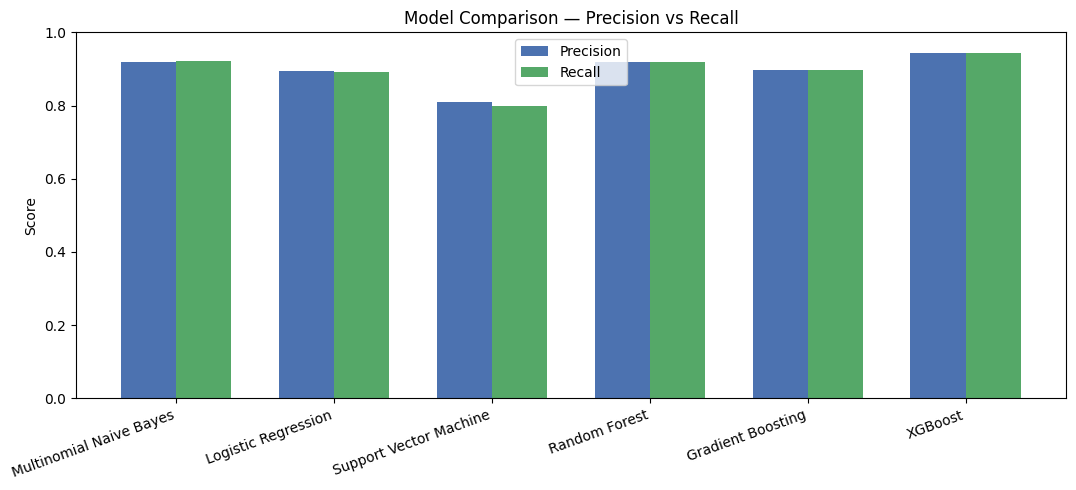

In [109]:
x = np.arange(len(results_df))
width = 0.35

sorted_df = results_df.sort_values("Model")

fig, ax = plt.subplots(figsize=(11,5))

ax.bar(
    x - width/2,
    sorted_df["Precision"].values,
    width,
    label="Precision",
    color="#4C72B0"
)

ax.bar(
    x + width/2,
    sorted_df["Recall"].values,
    width,
    label="Recall",
    color="#55A868"
)

ax.set_title("Model Comparison — Precision vs Recall", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(models_short, rotation=20, ha='right')

ax.set_ylim(0,1)
ax.set_ylabel("Score")

ax.legend()

plt.tight_layout()
plt.show()

# Conclusion

This study explored the use of machine learning models to automatically classify patents into different **novelty tiers** based on their textual content. Using TF-IDF feature extraction and Chi-square feature selection, multiple models were trained and fine-tuned to evaluate their effectiveness for patent novelty classification.

Among the evaluated models, **XGBoost achieved the best overall performance**, with the highest accuracy and macro F1 score, demonstrating its ability to capture complex patterns in patent text. **Random Forest and Gradient Boosting** also performed strongly, indicating that ensemble methods are particularly effective for this classification task. Linear models such as **Logistic Regression and SVM** showed good performance, while **Multinomial Naive Bayes served as a strong baseline model**.

The results highlight that advanced ensemble models can significantly improve classification accuracy when working with high-dimensional textual data. Overall, the proposed approach demonstrates the potential of machine learning techniques to assist in **automated patent novelty assessment**, helping support faster and more scalable patent analysis.

# Saving Fine-Tuned Models

After hyperparameter tuning and evaluation, the trained models are saved using **Joblib**.  
Saving the models allows them to be reused later for prediction without retraining.

In addition to the models, the **TF-IDF vectorizer and feature selector** are also saved to ensure that new input data can be processed in the same way as during training.

In [ ]:
save_path = "saved_models"
os.makedirs(save_path, exist_ok=True)

In [111]:
for name, model in best_models.items():
    
    filename = os.path.join(
        save_path,
        f"{name.replace(' ', '_')}_model.pkl"
    )
    
    joblib.dump(model, filename)
    
    print(f"{name} saved to {filename}")


Multinomial Naive Bayes saved to saved_models\Multinomial_Naive_Bayes_model.pkl
Logistic Regression saved to saved_models\Logistic_Regression_model.pkl
Support Vector Machine saved to saved_models\Support_Vector_Machine_model.pkl
Random Forest saved to saved_models\Random_Forest_model.pkl
Gradient Boosting saved to saved_models\Gradient_Boosting_model.pkl
XGBoost saved to saved_models\XGBoost_model.pkl


In [112]:
vectorizer_path = os.path.join(save_path, "tfidf_vectorizer.pkl")
joblib.dump(vectorizer, vectorizer_path)

print(f"TF-IDF Vectorizer saved to {vectorizer_path}")


TF-IDF Vectorizer saved to saved_models\tfidf_vectorizer.pkl


In [113]:
selector_path = os.path.join(save_path, "chi2_selector.pkl")
joblib.dump(selector, selector_path)

print(f"Feature Selector saved to {selector_path}")


print("\nAll models and preprocessing objects saved successfully.")

Feature Selector saved to saved_models\chi2_selector.pkl

All models and preprocessing objects saved successfully.
